In [80]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np

In [ ]:
# How does her music become more explicit across albums?

In [5]:
taylor = pd.read_csv("taylor_album_songs.csv")
display(taylor)

,album_name,ep,album_release,track_number,track_name,artist,featuring,bonus_track,promotional_release,single_release,...,liveness,valence,tempo,time_signature,duration_ms,explicit,key_name,mode_name,key_mode,lyrics
0,Taylor Swift,False,2006-10-24,1,Tim McGraw,Taylor Swift,NaN,False,NaN,2006-06-19,...,0.1210,0.425,76.009,4.0,232107.0,False,C,major,C major,NaN
1,Taylor Swift,False,2006-10-24,2,Picture To Burn,Taylor Swift,NaN,False,NaN,2008-02-03,...,0.0962,0.821,105.586,4.0,173067.0,False,G,major,G major,NaN
2,Taylor Swift,False,2006-10-24,3,Teardrops On My Guitar,Taylor Swift,NaN,False,NaN,2007-02-19,...,0.1190,0.289,99.953,4.0,203040.0,False,A#,major,A# major,NaN
3,Taylor Swift,False,2006-10-24,4,A Place In This World,Taylor Swift,NaN,False,NaN,NaN,...,0.3200,0.428,115.028,4.0,199200.0,False,A,major,A major,NaN
4,Taylor Swift,False,2006-10-24,5,Cold As You,Taylor Swift,NaN,False,NaN,NaN,...,0.1230,0.261,175.558,4.0,239013.0,False,F,major,F major,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,Midnights,False,2022-10-21,19,"Would've, Could've, Should've",Taylor Swift,NaN,True,NaN,NaN,...,0.1460,0.550,157.979,4.0,260362.0,False,G,major,G major,NaN
190,Midnights,False,2022-10-21,20,Dear Reader,Taylor Swift,NaN,True,NaN,NaN,...,0.1170,0.159,107.747,4.0,225194.0,False,C,major,C major,NaN
191,Midnights,False,2022-10-21,14,Hits Different,NaN,NaN,True,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
192,Midnights,False,2022-10-21,15,"You're On Your Own, Kid (Strings Remix)",NaN,NaN,True,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
taylor_cleaned = taylor.dropna(subset=['explicit'])
taylor_cleaned = taylor_cleaned.drop(columns=['ep', 'featuring', 'bonus_track','promotional_release', 'single_release', 'instrumentalness', 'lyrics'])
display(taylor_cleaned)

,album_name,album_release,track_number,track_name,artist,track_release,danceability,energy,key,loudness,...,acousticness,liveness,valence,tempo,time_signature,duration_ms,explicit,key_name,mode_name,key_mode
0,Taylor Swift,2006-10-24,1,Tim McGraw,Taylor Swift,2006-06-19,0.580,0.491,0.0,-6.462,...,0.575,0.1210,0.425,76.009,4.0,232107.0,False,C,major,C major
1,Taylor Swift,2006-10-24,2,Picture To Burn,Taylor Swift,2006-10-24,0.658,0.877,7.0,-2.098,...,0.173,0.0962,0.821,105.586,4.0,173067.0,False,G,major,G major
2,Taylor Swift,2006-10-24,3,Teardrops On My Guitar,Taylor Swift,2006-10-24,0.621,0.417,10.0,-6.941,...,0.288,0.1190,0.289,99.953,4.0,203040.0,False,A#,major,A# major
3,Taylor Swift,2006-10-24,4,A Place In This World,Taylor Swift,2006-10-24,0.576,0.777,9.0,-2.881,...,0.051,0.3200,0.428,115.028,4.0,199200.0,False,A,major,A major
4,Taylor Swift,2006-10-24,5,Cold As You,Taylor Swift,2006-10-24,0.418,0.482,5.0,-5.769,...,0.217,0.1230,0.261,175.558,4.0,239013.0,False,F,major,F major
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,Midnights,2022-10-21,16,Paris,Taylor Swift,2022-10-21,0.700,0.509,7.0,-10.547,...,0.112,0.1370,0.345,110.947,4.0,196259.0,False,G,major,G major
187,Midnights,2022-10-21,17,High Infidelity,Taylor Swift,2022-10-21,0.646,0.529,10.0,-10.179,...,0.723,0.0885,0.755,87.862,4.0,231475.0,False,A#,major,A# major
188,Midnights,2022-10-21,18,Glitch,Taylor Swift,2022-10-21,0.675,0.466,11.0,-9.738,...,0.361,0.1100,0.347,140.864,4.0,148781.0,False,B,minor,B minor
189,Midnights,2022-10-21,19,"Would've, Could've, Should've",Taylor Swift,2022-10-21,0.483,0.840,7.0,-6.508,...,0.430,0.1460,0.550,157.979,4.0,260362.0,False,G,major,G major


In [51]:
explicit = taylor_cleaned.groupby(['album_name' ,'album_release'])['explicit'].agg(['sum', 'count'])
explicit['percent'] = explicit['sum'] / explicit['count']
display(explicit)

,,sum,count,percent
album_name,album_release,,,
1989,2014-10-27,0,16,0.0
Fearless (Taylor's Version),2021-04-09,0,26,0.0
Lover,2019-08-23,0,18,0.0
Midnights,2022-10-21,6,20,0.3
Red (Taylor's Version),2021-11-12,2,30,0.066667
Speak Now,2010-10-25,0,17,0.0
Taylor Swift,2006-10-24,0,15,0.0
evermore,2020-12-11,6,17,0.352941
folklore,2020-07-24,5,17,0.294118


In [ ]:
explicit = explicit.reset_index('album_release')
explicit = explicit.sort_values('album_release')

In [53]:
print(explicit.columns)
print(explicit.index)

display(explicit)

Index(['album_release', 'sum', 'count', 'percent'], dtype='object')
Index(['Taylor Swift', 'Speak Now', '1989', 'reputation', 'Lover', 'folklore',
       'evermore', 'Fearless (Taylor's Version)', 'Red (Taylor's Version)',
       'Midnights'],
      dtype='object', name='album_name')


,album_release,sum,count,percent
album_name,,,,
Taylor Swift,2006-10-24,0,15,0.0
Speak Now,2010-10-25,0,17,0.0
1989,2014-10-27,0,16,0.0
reputation,2017-11-10,0,15,0.0
Lover,2019-08-23,0,18,0.0
folklore,2020-07-24,5,17,0.294118
evermore,2020-12-11,6,17,0.352941
Fearless (Taylor's Version),2021-04-09,0,26,0.0
Red (Taylor's Version),2021-11-12,2,30,0.066667


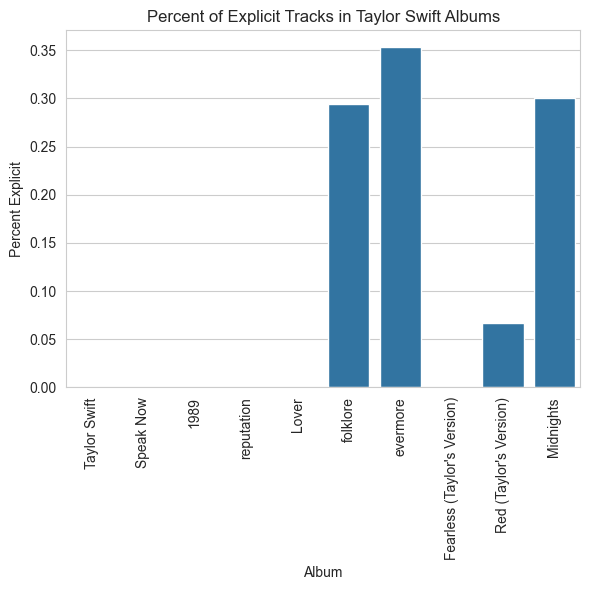

In [78]:
fig, ax = plt.subplots(figsize=(6,6))

sns.barplot(data=explicit, x='album_name', y='percent', ax=ax)

ax.set_ylabel('Percent Explicit')
ax.set_xlabel('Album')
ax.set_title('Percent of Explicit Tracks in Taylor Swift Albums')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()